# Fine-tuning Pre-trained Model for Perturbation Prediction

In [1]:
import json
import os
import sys
import time
import copy
from pathlib import Path
from typing import Iterable, List, Tuple, Dict, Union, Optional
import warnings

import torch
import numpy as np
import matplotlib
from torch import nn
from torch.nn import functional as F

from torch_geometric.loader import DataLoader
from gears import PertData, GEARS
from gears.inference import compute_metrics, deeper_analysis, non_dropout_analysis
from gears.utils import create_cell_graph_dataset_for_prediction

sys.path.insert(0, "../")
from cancerfoundation.gene_tokenizer import GeneVocab
from cancerfoundation.model.module import TransformerModule
from cancerfoundation.loss import masked_mse_loss

matplotlib.rcParams["savefig.transparent"] = False
warnings.filterwarnings("ignore")

# set_seed(42)


/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module


In [13]:
def map_raw_id_to_vocab_id(
    raw_ids: Union[np.ndarray, torch.Tensor],
    gene_ids: np.ndarray,
) -> Union[np.ndarray, torch.Tensor]:
    """
    Map some raw ids which are indices of the raw gene names to the indices of the

    Args:
        raw_ids: the raw ids to map
        gene_ids: the gene ids to map to
    """
    if isinstance(raw_ids, torch.Tensor):
        device = raw_ids.device
        dtype = raw_ids.dtype
        return_pt = True
        raw_ids = raw_ids.cpu().numpy()
    elif isinstance(raw_ids, np.ndarray):
        return_pt = False
        dtype = raw_ids.dtype
    else:
        raise ValueError(f"raw_ids must be either torch.Tensor or np.ndarray.")

    if raw_ids.ndim != 1:
        raise ValueError(f"raw_ids must be 1d, got {raw_ids.ndim}d.")

    if gene_ids.ndim != 1:
        raise ValueError(f"gene_ids must be 1d, got {gene_ids.ndim}d.")

    mapped_ids: np.ndarray = gene_ids[raw_ids]
    assert mapped_ids.shape == raw_ids.shape
    if return_pt:
        return torch.from_numpy(mapped_ids).type(dtype).to(device)
    return mapped_ids.astype(dtype)

 ## Training Settings

In [14]:
# settings for data prcocessing
pad_token = "<pad>"
# special_tokens = [pad_token, "<cls>", "<eoc>"]
special_tokens = [pad_token, "<cls>"]
pad_value = 1  # for padding values
pert_pad_id = 0
include_zero_gene = "all"
max_seq_len = 1200

# settings for training
MLM = True  # whether to use masked language modeling, currently it is always on.
CLS = False  # celltype classification objective
CCE = False  # Contrastive cell embedding objective
MVC = False  # Masked value prediction for cell embedding
ECS = False  # Elastic cell similarity objective
amp = True
load_model = "../save/train_brain_base_7336129"
load_param_prefixs = [
    "encoder",
    "value_encoder",
    "transformer_encoder",
]

# settings for optimizer
lr = 1e-4  # or 1e-4
batch_size = 64
eval_batch_size = 64
epochs = 15
schedule_interval = 1
early_stop = 10

# logging
log_interval = 100

# dataset and evaluation choices
data_name = "adamson"
split = "simulation"
if data_name == "norman":
    perts_to_plot = ["SAMD1+ZBTB1"]
elif data_name == "adamson":
    perts_to_plot = ["KCTD16+ctrl"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [15]:
save_dir = Path(f"./save/dev_perturb_{data_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"saving to {save_dir}")

# log running date and current git commit
print(f"Running on {time.strftime('%Y-%m-%d %H:%M:%S')}")



saving to save/dev_perturb_adamson-Oct07-08-57
Running on 2025-10-07 08:57:28


In [16]:
pert_data = PertData("./data")
pert_data.load(data_name=data_name)
pert_data.prepare_split(split=split, seed=1)
pert_data.get_dataloader(batch_size=batch_size, test_batch_size=eval_batch_size)


Found local copy...


Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:0
combo_seen1:0
combo_seen2:0
unseen_single:22
Done!
Creating dataloaders....
Done!


In [17]:
if load_model is not None:
    model_dir = Path(load_model)
    model_config_file = model_dir / "args.json"
    model_file = model_dir / "best_model.pt"
    vocab_file = model_dir / "vocab.json"

    with open(vocab_file, "r") as f:
        vocab = json.load(f)
    for s in special_tokens:
        if s not in vocab:
            vocab[s] = len(vocab)

    pert_data.adata.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in pert_data.adata.var["gene_name"]
    ]
    gene_ids_in_vocab = np.array(pert_data.adata.var["id_in_vocab"])
    print(
        f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
        f"in vocabulary of size {len(vocab)}."
    )
    genes = pert_data.adata.var["gene_name"].tolist()

    # model
    with open(model_config_file, "r") as f:
        model_configs = json.load(f)
    print(
        f"Resume model from {model_file}, the model args will override the "
        f"config {model_config_file}."
    )
    embsize = model_configs["embsize"]
    nhead = model_configs["nheads"]
    d_hid = model_configs["d_hid"]
    nlayers = model_configs["nlayers"]
    n_layers_cls = model_configs["n_layers_cls"]
    dropout = model_configs["dropout"]
else:
    genes = pert_data.adata.var["gene_name"].tolist()
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
# vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(
    [vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int
)
n_genes = len(genes)



match 2423/5060 genes in vocabulary of size 10002.
Resume model from ../save/train_brain_base_7336129/best_model.pt, the model args will override the config ../save/train_brain_base_7336129/args.json.


 # Create and train scGpt

In [18]:
from cancerfoundation.model.model import CancerFoundation
print(vocab)
CancerFoundation.load_from_checkpoint("../save/train_brain_base_7336129/epoch_epoch=49.ckpt", vocab=vocab)
ntokens = len(vocab)  # size of vocabulary
model = TransformerModule(
    ntoken=ntokens,
    d_model=embsize,
    out_dim=51,
    nhead=nhead,
    d_hid=d_hid,
    nlayers=nlayers,
    pad_value=pad_value,
    pad_token_id=vocab["<pad>"],
    criterion=masked_mse_loss,
    activation=F.relu,
    do_mvc=True,
    dropout=dropout,
    conditions=None,
    input_emb_style="category",
    n_input_bins=51,
    cell_emb_style="cls",
    mvc_decoder_style="inner product",
    explicit_zero_prob=False,
    use_generative_training=True,
    norm_first=False,
    do_dat=False,
    batchnorm=False,
    dat_scale=1.0,
    normalise_bins=False,
    no_invert_dat=True,
    where_condition="end",
    max_seq_len=1200,
    gen_method="theirs",
)
# if load_param_prefixs is not None and load_model is not None:
#     # only load params that start with the prefix
#     model_dict = model.state_dict()
    
#     print(model)
#     pretrained_dict = torch.load(model_file)
#     replaced_dict = {}
#     for k in pretrained_dict.keys():
#         if "Wqkv.weight" in k:
#             new_k = k.replace("Wqkv.weight", "in_proj_weight")
#             replaced_dict[new_k] = pretrained_dict[k]
#         elif "Wqkv.bias" in k:
#             new_k = k.replace("Wqkv.bias", "in_proj_bias")
#             replaced_dict[new_k] = pretrained_dict[k]
#         else:
#             replaced_dict[k] = pretrained_dict[k]
#     pretrained_dict = replaced_dict
#     pretrained_dict = {
#         k: v
#         for k, v in pretrained_dict.items()
#         if any([k.startswith(prefix) for prefix in load_param_prefixs])
#     }
#     for k, v in pretrained_dict.items():
#         print(f"Loading params {k} with shape {v.shape}")
#     model_dict.update(pretrained_dict)
#     model.load_state_dict(model_dict)
# elif load_model is not None:
#     pretrained_dict = torch.load(model_file)
#     try:
#         model.load_state_dict(torch.load(model_file))
#         print(f"Loading all model params from {model_file}")
#     except:
#         # only load params that are in the model and match the size
#         model_dict = model.state_dict()
#         pretrained_dict = torch.load(model_file)
#         pretrained_dict = {
#             k: v
#             for k, v in pretrained_dict.items()
#             if k in model_dict and v.shape == model_dict[k].shape
#         }
#         for k, v in pretrained_dict.items():
#             print(f"Loading params {k} with shape {v.shape}")
#         model_dict.update(pretrained_dict)
#         model.load_state_dict(model_dict)
model.to(device)



{'<cls>': 0, '<pad>': 1, 'KDM4C': 2, 'SEC24C': 3, 'GPC6': 4, 'BSG': 5, 'BCAN': 6, 'CHDH': 7, 'CCNE2': 8, 'APOOL': 9, 'JAK1': 10, 'GAL3ST4': 11, 'AQP1': 12, 'MYADM': 13, 'SPTSSA': 14, 'LIG1': 15, 'SCRG1': 16, 'RIOK1': 17, 'C12orf10': 18, 'ZFC3H1': 19, 'GOLGA7': 20, 'RASA4': 21, 'ZFYVE9': 22, 'PAK3': 23, 'KHSRP': 24, 'DCTN4': 25, 'NRIP3': 26, 'ANKRD35': 27, 'PIGF': 28, 'ARIH1': 29, 'CDKN2D': 30, 'LPIN1': 31, 'KPNA1': 32, 'GNG2': 33, 'TRUB2': 34, 'PHF5A': 35, 'CASP3': 36, 'PAQR8': 37, 'KIF14': 38, 'LINC00116': 39, 'ANKS6': 40, 'UBA3': 41, 'MTRF1': 42, 'GLRB': 43, 'RPS6KB1': 44, 'RHBDL3': 45, 'ADAL': 46, 'ZADH2': 47, 'ERCC2': 48, 'TECR': 49, 'SNX2': 50, 'TAOK2': 51, 'CCDC77': 52, 'MAT2A': 53, 'PAXIP1': 54, 'RGS19': 55, 'ASTN2': 56, 'BRWD3': 57, 'PDLIM7': 58, 'PIM1': 59, 'SSR2': 60, 'MLF2': 61, 'GTPBP10': 62, 'LIG3': 63, 'EDEM1': 64, 'FBXO7': 65, 'RANBP9': 66, 'PTPRA': 67, 'TRIM56': 68, 'LRRFIP1': 69, 'MEX3A': 70, 'FAM160A2': 71, 'GARNL3': 72, 'ENY2': 73, 'RNF165': 74, 'MAP2K1': 75, 'ZSWIM5

TransformerModule(
  (gene_encoder): GeneEncoder(
    (embedding): Embedding(10002, 128, padding_idx=1)
    (enc_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): CategoricalValueEncoder(
    (embedding): Embedding(51, 128, padding_idx=1)
    (enc_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (criterion_conditions): CrossEntropyLoss()
  (transformer_encoder): CFGenerator(
    (layers): ModuleList(
      (0-5): 6 x CFLayer(
        (self_attn): MHA(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_aff

In [21]:

criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, schedule_interval, gamma=0.9)
scaler = torch.cuda.amp.GradScaler(enabled=amp)


def train(model: nn.Module, train_loader: torch.utils.data.DataLoader) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    total_loss, total_mse = 0.0, 0.0
    start_time = time.time()

    num_batches = len(train_loader)
    for batch, batch_data in enumerate(train_loader):
        batch_size = len(batch_data.y)
        batch_data.to(device)
        x: torch.Tensor = batch_data.x  # (batch_size * n_genes, 2)
        ori_gene_values = x[:, 0].view(batch_size, n_genes)
        pert_flags = x[:, 1].long().view(batch_size, n_genes)
        target_gene_values = batch_data.y  # (batch_size, n_genes)

        if include_zero_gene in ["all", "batch-wise"]:
            if include_zero_gene == "all":
                input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
            else:
                input_gene_ids = (
                    ori_gene_values.nonzero()[:, 1].flatten().unique().sort()[0]
                )
            # sample input_gene_id
            if len(input_gene_ids) > max_seq_len:
                input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[
                    :max_seq_len
                ]
            input_values = ori_gene_values[:, input_gene_ids]
            input_pert_flags = pert_flags[:, input_gene_ids]
            target_values = target_gene_values[:, input_gene_ids]

            print(input_gene_ids)
            print(gene_ids)

            mapped_input_gene_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids)
            mapped_input_gene_ids = mapped_input_gene_ids.repeat(batch_size, 1)

            # src_key_padding_mask = mapped_input_gene_ids.eq(vocab[pad_token])
            src_key_padding_mask = torch.zeros_like(
                input_values, dtype=torch.bool, device=device
            )
        
        tens = {
            "gene": mapped_input_gene_ids,
            "masked_expr": input_values,
            "expr": target_values
        }

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                tens
                # mapped_input_gene_ids,
                # input_values,
                # input_pert_flags,
                # src_key_padding_mask=src_key_padding_mask,
                # CLS=CLS,
                # CCE=CCE,
                # MVC=MVC,
                # ECS=ECS,
            )
            output_values = output_dict["mlm_output"]

            masked_positions = torch.ones_like(
                input_values, dtype=torch.bool
            )  # Use all
            loss = loss_mse = criterion(output_values, target_values, masked_positions)

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                print(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )
        scaler.step(optimizer)
        scaler.update()

        # torch.cuda.empty_cache()

        total_loss += loss.item()
        total_mse += loss_mse.item()
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            # ppl = math.exp(cur_loss)
            print(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | mse {cur_mse:5.2f} |"
            )
            total_loss = 0
            total_mse = 0
            start_time = time.time()


def eval_perturb(
    loader: DataLoader, model, device: torch.device
) -> Dict:
    """
    Run model in inference mode using a given data loader
    """

    model.eval()
    model.to(device)
    pert_cat = []
    pred = []
    truth = []
    pred_de = []
    truth_de = []
    results = {}
    logvar = []

    for itr, batch in enumerate(loader):
        batch.to(device)
        pert_cat.extend(batch.pert)

        with torch.no_grad():
            p = model.pred_perturb(
                batch,
                include_zero_gene=include_zero_gene,
                gene_ids=gene_ids,
            )
            t = batch.y
            pred.extend(p.cpu())
            truth.extend(t.cpu())

            # Differentially expressed genes
            for itr, de_idx in enumerate(batch.de_idx):
                pred_de.append(p[itr, de_idx])
                truth_de.append(t[itr, de_idx])

    # all genes
    results["pert_cat"] = np.array(pert_cat)
    pred = torch.stack(pred)
    truth = torch.stack(truth)
    results["pred"] = pred.detach().cpu().numpy().astype(np.float)
    results["truth"] = truth.detach().cpu().numpy().astype(np.float)

    pred_de = torch.stack(pred_de)
    truth_de = torch.stack(truth_de)
    results["pred_de"] = pred_de.detach().cpu().numpy().astype(np.float)
    results["truth_de"] = truth_de.detach().cpu().numpy().astype(np.float)

    return results



In [22]:
best_val_loss = float("inf")
best_val_corr = 0
best_model = None
patience = 0

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_loader = pert_data.dataloader["train_loader"]
    valid_loader = pert_data.dataloader["val_loader"]

    train(
        model,
        train_loader,
    )

    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_perturbation_metrics(
        val_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
    )
    print(f"val_metrics at epoch {epoch}: ")
    print(val_metrics)

    elapsed = time.time() - epoch_start_time
    print(f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | ")

    val_score = val_metrics["pearson"]
    if val_score > best_val_corr:
        best_val_corr = val_score
        best_model = copy.deepcopy(model)
        print(f"Best model with score {val_score:5.4f}")
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            print(f"Early stop at epoch {epoch}")
            break

    # torch.save(
    #     model.state_dict(),
    #     save_dir / f"model_{epoch}.pt",
    # )

    scheduler.step()



tensor([2674,  876, 4592,  ..., 4354, 3561, 2740], device='cuda:0')
[   1    1    1 ...    1  402 5063]


KeyError: 'pcpt_gene'

In [ ]:
torch.save(best_model.state_dict(), save_dir / "best_model.pt")


 ## Evaluations

In [ ]:
def predict(
    model: TransformerGenerator, pert_list: List[str], pool_size: Optional[int] = None
) -> Dict:
    """
    Predict the gene expression values for the given perturbations.

    Args:
        model (:class:`torch.nn.Module`): The model to use for prediction.
        pert_list (:obj:`List[str]`): The list of perturbations to predict.
        pool_size (:obj:`int`, optional): For each perturbation, use this number
            of cells in the control and predict their perturbation results. Report
            the stats of these predictions. If `None`, use all control cells.
    """
    adata = pert_data.adata
    ctrl_adata = adata[adata.obs["condition"] == "ctrl"]
    if pool_size is None:
        pool_size = len(ctrl_adata.obs)
    gene_list = pert_data.gene_names.values.tolist()
    for pert in pert_list:
        for i in pert:
            if i not in gene_list:
                raise ValueError(
                    "The gene is not in the perturbation graph. Please select from GEARS.gene_list!"
                )

    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        results_pred = {}
        for pert in pert_list:
            cell_graphs = create_cell_graph_dataset_for_prediction(
                pert, ctrl_adata, gene_list, device, num_samples=pool_size
            )
            loader = DataLoader(cell_graphs, batch_size=eval_batch_size, shuffle=False)
            preds = []
            for batch_data in loader:
                pred_gene_values = model.pred_perturb(
                    batch_data, include_zero_gene, gene_ids=gene_ids, amp=amp
                )
                preds.append(pred_gene_values)
            preds = torch.cat(preds, dim=0)
            results_pred["_".join(pert)] = np.mean(preds.detach().cpu().numpy(), axis=0)

    return results_pred



In [ ]:
def plot_perturbation(
    model: nn.Module, query: str, save_file: str = None, pool_size: int = None
) -> matplotlib.figure.Figure:
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font_scale=1.5)

    adata = pert_data.adata
    gene2idx = pert_data.node_map
    cond2name = dict(adata.obs[["condition", "condition_name"]].values)
    gene_raw2id = dict(zip(adata.var.index.values, adata.var.gene_name.values))

    de_idx = [
        gene2idx[gene_raw2id[i]]
        for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    genes = [
        gene_raw2id[i] for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    truth = adata[adata.obs.condition == query].X.toarray()[:, de_idx]
    if query.split("+")[1] == "ctrl":
        pred = predict(model, [[query.split("+")[0]]], pool_size=pool_size)
        pred = pred[query.split("+")[0]][de_idx]
    else:
        pred = predict(model, [query.split("+")], pool_size=pool_size)
        pred = pred["_".join(query.split("+"))][de_idx]
    ctrl_means = adata[adata.obs["condition"] == "ctrl"].to_df().mean()[de_idx].values

    pred = pred - ctrl_means
    truth = truth - ctrl_means

    fig, ax = plt.subplots(figsize=[16.5, 4.5])
    plt.title(query)
    plt.boxplot(truth, showfliers=False, medianprops=dict(linewidth=0))

    for i in range(pred.shape[0]):
        _ = plt.scatter(i + 1, pred[i], color="red")

    plt.axhline(0, linestyle="dashed", color="green")

    ax.xaxis.set_ticklabels(genes, rotation=90)

    plt.ylabel("Change in Gene Expression over Control", labelpad=10)
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tick_params(axis="y", which="major", pad=5)
    sns.despine()

    if save_file:
        fig.savefig(save_file, bbox_inches="tight", transparent=False)

    return fig

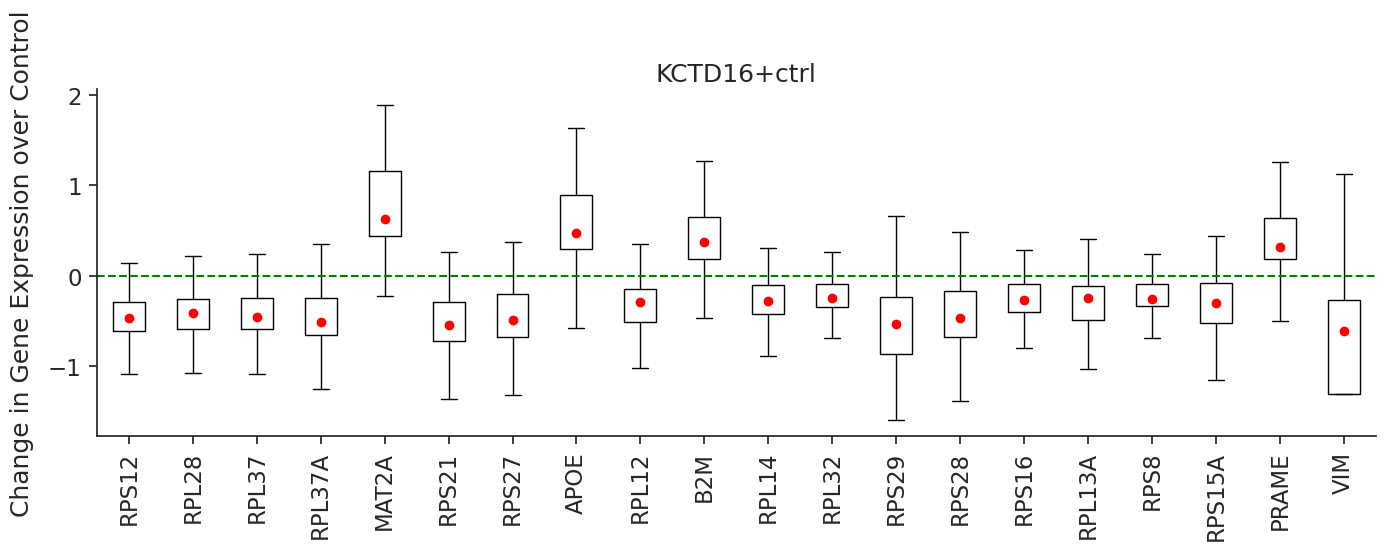

In [ ]:
# predict(best_model, [["FEV"], ["FEV", "SAMD11"]])
for p in perts_to_plot:
    plot_perturbation(best_model, p, pool_size=300, save_file=f"{save_dir}/{p}.png")



In [ ]:
test_loader = pert_data.dataloader["test_loader"]
test_res = eval_perturb(test_loader, best_model, device)
# test_metrics, test_pert_res = compute_metrics(test_res)
test_metrics = compute_perturbation_metrics(
    test_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
)
print(test_metrics)

# save the dicts in json
with open(f"{save_dir}/test_metrics.json", "w") as f:
    json.dump(test_metrics, f)
# with open(f"{save_dir}/test_pert_res.json", "w") as f:
#     json.dump(test_pert_res, f)

deeper_res = deeper_analysis(pert_data.adata, test_res)
non_dropout_res = non_dropout_analysis(pert_data.adata, test_res)

metrics = ["pearson_delta", "pearson_delta_de"]
metrics_non_dropout = [
    "pearson_delta_top20_de_non_dropout",
    "pearson_top20_de_non_dropout",
]
subgroup_analysis = {}
for name in pert_data.subgroup["test_subgroup"].keys():
    subgroup_analysis[name] = {}
    for m in metrics:
        subgroup_analysis[name][m] = []

    for m in metrics_non_dropout:
        subgroup_analysis[name][m] = []

for name, pert_list in pert_data.subgroup["test_subgroup"].items():
    for pert in pert_list:
        for m in metrics:
            subgroup_analysis[name][m].append(deeper_res[pert][m])

        for m in metrics_non_dropout:
            subgroup_analysis[name][m].append(non_dropout_res[pert][m])

for name, result in subgroup_analysis.items():
    for m in result.keys():
        mean_value = np.mean(subgroup_analysis[name][m])
        logger.info("test_" + name + "_" + m + ": " + str(mean_value))


{'pearson': 0.9904118130127787, 'pearson_de': 0.9794049791961658, 'pearson_delta': 0.6418570216674039, 'pearson_de_delta': 0.7973933739812668}
scGPT - INFO - test_combo_seen0_pearson_delta: nan
scGPT - INFO - test_combo_seen0_pearson_delta_de: nan
scGPT - INFO - test_combo_seen0_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen0_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen1_pearson_delta: nan
scGPT - INFO - test_combo_seen1_pearson_delta_de: nan
scGPT - INFO - test_combo_seen1_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen1_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen2_pearson_delta: nan
scGPT - INFO - test_combo_seen2_pearson_delta_de: nan
scGPT - INFO - test_combo_seen2_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen2_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_unseen_single_pearson_delta: 0.6418570216674039
scGPT - INFO - test_unseen_single_pearson_delta_de: 0.797393